**НАДО СДЕЛАТЬ ЭТО ЗАДАНИЕ С CNN вместо fully-connected ДЛЯ ИНТЕРЕСА (и сделать бонусы)**

# <p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1TRNaCfYstvcIQqoUSdukYQGF6LuyL7Tv" width=600 height=320/></p>
<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

# Домашнее задание. Автоэнкодеры


# Часть 1. Vanilla Autoencoder (10 баллов)

## 1.1. Подготовка данных (1 балл)


In [5]:
import numpy as np
from torch.autograd import Variable
from torchvision import datasets
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data_utils
import torch
import matplotlib.pyplot as plt

import os
import pandas as pd
import skimage.io
from skimage.transform import resize


%matplotlib inline

In [125]:
def fetch_dataset(attrs_name = "lfw_attributes.txt",
                      images_name = "lfw-deepfunneled",
                      dx=80,dy=80,
                      dimx=64,dimy=64
    ):

    #download if not exists
    #if not os.path.exists(images_name):
    #    print("images not found, donwloading...")
    #    os.system("wget http://vis-www.cs.umass.edu/lfw/lfw-deepfunneled.tgz -O tmp.tgz")
    #    print("extracting...")
    #    os.system("tar xvzf lfw-deepfunneled.tgz")
    #    print("done")
    #    assert os.path.exists(images_name)

    #if not os.path.exists(attrs_name):
    #    print("attributes not found, downloading...")
    #    os.system("wget http://www.cs.columbia.edu/CAVE/databases/pubfig/download/%s" % attrs_name)
    #    print("done")

    #read attrs
    df_attrs = pd.read_csv("lfw_attributes.txt",sep='\t',skiprows=1,) #пропускаем первую строчку файла, не относящуюся к таблице (там просто ссылка на сайт)
    df_attrs = pd.DataFrame(df_attrs.iloc[:,:-1].values, columns = df_attrs.columns[1:]) #почему-то берём все атрибуты, кроме последнего столбика. Наверное там пустая строка, а не число. В качестве колонок берём названия столбиков, кроме первого, потому что первый - это решётка, она не относится к таблице


    #read photos
    photo_ids = []
    for dirpath, dirnames, filenames in os.walk(images_name): #посещаем все подпапки любого уровня вложенности папки images_name=lfw-deepfunneled. os.walk возвращает генератор, который выдаёт кортеж = (весь путь до текущей подпапки, список подпапки текущей подпапки, список файлов текущей подпапки). То есть второй и третий элемент кортежа - это объекты одного уровня вложенности
        for fname in filenames: #filenames = ['john_silver_0001.jpg, 'john_silver_0002.jpg, ...]
            if fname.endswith(".jpg"):
                fpath = os.path.join(dirpath,fname) #записываем весь путь до текущего файла, включая сам файл
                photo_id = fname[:-4].replace('_',' ').split() #'john_silver_0001.jpg' -> 'john_silver_0001' -> 'john silver 0001' -> ['john', 'silver', '0001']. обрезаем расширение изображения вместе с точкой из его названия, меняем '_' на ' ' и сплитим
                person_id = ' '.join(photo_id[:-1]) #['john', 'silver', '0001'] -> 'john silver'
                photo_number = int(photo_id[-1]) #'0001' -> 1
                photo_ids.append({'person':person_id,'imagenum':photo_number,'photo_path':fpath})

    photo_ids = pd.DataFrame(photo_ids)
    # print(photo_ids)
    #mass-merge
    #(photos now have same order as attributes)
    df = pd.merge(df_attrs,photo_ids,on=('person','imagenum')) #merge - это комбинаторная штука, но в данном случае она просто добавила столбик photo_path в df_attrs

    assert len(df)==len(df_attrs),"lost some data when merging dataframes"

    # print(df.shape)
    #image preprocessing
    #apply применяет фукнцию к элементам таблицы. simage.io.imread(image_path) читает изображение и возвращает HxWxC np.array, заполненный кодами RGB цветов картинки
    #срезали у картинки со всех сторон по краям по dy=80 и dx=80 пикселей
    #как-то по-умному не обрезали, а поджали (растянули) изображение до нужного размера [dimx, dimy] = [64, 64]
    all_photos =df['photo_path'].apply(skimage.io.imread)\
                                .apply(lambda img:img[dy:-dy,dx:-dx])\
                                .apply(lambda img: resize(img,[dimx,dimy]))

    all_photos = np.stack(all_photos.values)#.astype('uint8') #.values возвращает значения таблицы в виде двумероного np.array, где a[i] - это числа строки i. stack должен соединять списки одинакового размера друг с другом, созавая список размерности на 1 больше. Если представлять двумерные списки, то их как бы складывают друг на друга. А зачем нужен stack здесь я не понимаю, мне кажется values и так вернул подходящий список по размерности
    all_attrs = df.drop(["photo_path","person","imagenum"],axis=1)

    return all_photos, all_attrs #все обрезанные фотографии в виде np.array, все атрибуты этих фотографий

In [126]:
# The following line fetches you two datasets: images, usable for autoencoder training and attributes.
# Those attributes will be required for the final part of the assignment (applying smiles), so please keep them in mind


data, attrs = fetch_dataset()


Разбейте выборку картинок на train и val, выведите несколько картинок в output, чтобы посмотреть, как они выглядят, и приведите картинки к тензорам pytorch, чтобы можно было скормить их сети:

In [127]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

data_tensor = torch.Tensor(data)
train_data, val_data, train_attrs, val_attrs = train_test_split(data_tensor, attrs, test_size=0.2, random_state=42)
train_data_loader = DataLoader(train_data, batch_size=32)
val_data_loader = DataLoader(val_data, batch_size=32)

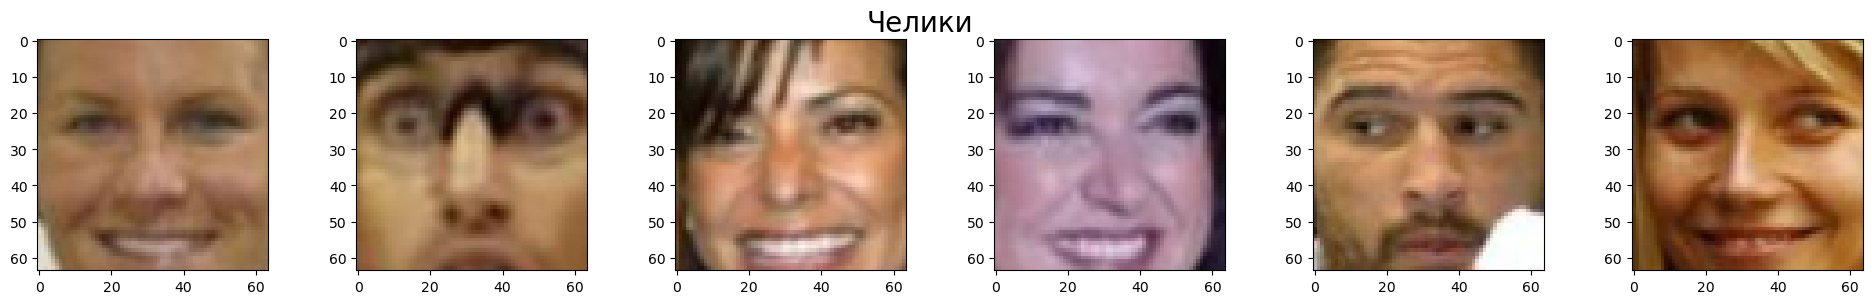

In [5]:
val_data_batch = next(iter(val_data_loader))
fig, axes = plt.subplots(figsize=[4 * 6, 3 * 1], nrows=1, ncols=6)
axes = axes.flatten()
for i in range(len(axes)):
    axes[i].imshow(val_data_batch[i])

fig.suptitle('Челики', fontsize=20)
plt.show()

In [ ]:
PRE_TRAINED1 = True

## 1.2. Архитектура модели (2 балла)
В этом разделе мы напишем и обучем обычный автоэнкодер.



<img src="https://www.notion.so/image/https%3A%2F%2Fs3-us-west-2.amazonaws.com%2Fsecure.notion-static.com%2F4b8adf79-8e6a-4b7d-9061-8617a00edbb1%2F__2021-04-30__14.53.33.png?table=block&id=56f187b4-279f-4208-b1ed-4bda5f91bfc0&width=2880&userId=3b1b5e32-1cfb-4b0f-8705-5a524a8f56e3&cache=v2" alt="Autoencoder">


^ напомню, что автоэнкодер выглядит вот так

In [6]:
dim_code = (22, 22, 3) # выберите размер латентного вектора

Реализуем autoencoder. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Экспериментируйте!

In [7]:
from copy import deepcopy

class AutoencoderLinear(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(64*64*3, 2048*3),
            nn.ReLU(),
            nn.Linear(2048*3, 1024*3),
            nn.ReLU(),
            nn.Linear(1024*3, 22*22*3) #512*3),
            #nn.ReLU(),
            #nn.Linear(512*3, 256*3),
            #nn.ReLU(),
            #nn.Linear(256*3, 121*3),
            #nn.Sigmoid()
        )
        self.decoder = nn.Sequential(
            #nn.Linear(121*3, 256*3),
            #nn.ReLU(),
            #nn.Linear(256*3, 512*3),
            #nn.ReLU(),
            #nn.Linear(512*3, 1024*3),
            nn.Linear(22*22*3, 1024*3),
            nn.ReLU(),
            nn.Linear(1024*3, 2048*3),
            nn.ReLU(),
            nn.Linear(2048*3, 64*64*3),
            #nn.Sigmoid()
        )
        # Обратите внимание на формат, в котором функция fetch() возвращает data

    def forward(self, x):
        first_flatten_dim, latent_code = self.encode(x)
        reconstruction = self.decode(first_flatten_dim, latent_code)
        return reconstruction, latent_code

    def encode(self, x):
        first_flatten_dim = 1 if len(x.size()) == 4 else 0
        x = nn.Flatten(first_flatten_dim, -1)(x)
        latent_code = self.ecnoder(x)
        return first_flatten_dim, latent_code

    def decode(self, first_flatten_dim, latent_code):
        reconstruction = self.decoder(latent_code)
        return nn.Unflatten(first_flatten_dim, (64, 64, 3))(reconstruction)

In [121]:
def BasicBlock(in_features, out_features):
        return nn.Sequential(
            nn.Conv2d(in_features, out_features, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_features),
            nn.ReLU()
        )

class AutoencoderConv(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc_conv0 = BasicBlock(3, 16) #64*64*3 -> 64*64*16
        self.enc_pool0 = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True) #64*64*16 -> 32*32*16
        self.enc_conv1 = BasicBlock(16, 32) #32*32*16 -> 32*32*32
        self.enc_pool1 = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True) #32*32*32 -> 16*16*32
        self.enc_conv2 = BasicBlock(32, 64) #16*16*32 -> 16*16*64
        self.enc_pool2 = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True) #16*16*64 -> 8*8*64
        
        self.dec_upsample0 = nn.MaxUnpool2d(kernel_size=2, stride=2)
        self.dec_conv0 = BasicBlock(64, 32)
        self.dec_upsample1 = nn.MaxUnpool2d(kernel_size=2, stride=2)
        self.dec_conv1 = BasicBlock(32, 16)
        self.dec_upsample2 = nn.MaxUnpool2d(kernel_size=2, stride=2)
        self.dec_conv2 = nn.Conv2d(16, 3, kernel_size=3, padding=1)
        # Обратите внимание на формат, в котором функция fetch() возвращает data

    def forward(self, x):
        latent_code, inds = self.encode(x)
        reconstruction = self.decode(inds, latent_code)
        return reconstruction, latent_code

    def encode(self, x):
        x = x.view(-1, 3, 64, 64)
        e0, ind0 = self.enc_pool0(self.enc_conv0(x))
        e1, ind1 = self.enc_pool1(self.enc_conv1(e0))
        e2, ind2 = self.enc_pool2(self.enc_conv2(e1))
        return e2, [ind0, ind1, ind2]

    def decode(self, inds, latent_code):
        d0 = self.dec_conv0(self.dec_upsample0(latent_code, inds[2]))
        d1 = self.dec_conv1(self.dec_upsample1(d0, inds[1]))
        d2 = self.dec_conv2(self.dec_upsample2(d1, inds[0]))
        return d2

In [6]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(DEVICE)

cuda


In [80]:
def myBCELoss(y_real, y_pred):
    return nn.BCEWithLogitsLoss()(y_real.view(-1, 3, 64, 64), y_pred)

In [11]:
def bce_loss(y_real, y_pred):
    #y_pred = y_pred.view(-1, 3, 64, 64)
    return (y_pred * (y_pred > 0).float() - y_real * y_pred + torch.log(1 + torch.exp(-torch.abs(y_pred)))).mean() # TODO

In [83]:
import gc
autoencoder_linear = autoencoder_linear.to('cpu')
del autoencoder_linear
torch.cuda.empty_cache()
gc.collect()

criterion = nn.MSELoss(reduction='sum') #nn.MSELoss() #или все-таки другая?!
autoencoder_linear = AutoencoderLinear().to(DEVICE)
optimizer = torch.optim.Adam(autoencoder_linear.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5) #step_size=10
max_epochs = 40

## 1.3 Обучение (2 балла)

Осталось написать код обучения автоэнкодера. При этом было бы неплохо в процессе иногда смотреть, как автоэнкодер реконструирует изображения на данном этапе обучения. Наример, после каждой эпохи (прогона train выборки через автоэекодер) можно смотреть, какие реконструкции получились для каких-то изображений val выборки.

А, ну еще было бы неплохо выводить графики train и val лоссов в процессе тренировки =)

In [7]:
from IPython.display import clear_output

def train(model, opt, scheduler, loss_fn, epochs, data_tr, data_val):
    train_loss_history, val_loss_history = [], []
    val_batch = next(iter(data_val))

    for epoch in range(epochs):
        model.train()
        avg_loss = 0
        for X_batch in data_tr:
            X_batch = X_batch.to(DEVICE)
            opt.zero_grad()
            output, _ = model(X_batch)
            loss = loss_fn(X_batch, output)
            loss.backward()
            opt.step()
            avg_loss += loss
        avg_loss /= len(data_tr)
        if epoch != 0:
            train_loss_history.append(avg_loss.item())

        model.eval()
        avg_loss = 0
        for X_batch in data_val:
            X_batch = X_batch.to(DEVICE)
            output, _ = model(X_batch)
            loss = loss_fn(X_batch, output)
            avg_loss += loss
        avg_loss /= len(data_val)
        if epoch != 0:
            val_loss_history.append(avg_loss.item())

        clear_output(wait=True)
        print('Epoch:', epoch+1)
        plt.figure(figsize=[4 * 6, 3 * 4])
        if epoch != 0:
            plt.subplot(4, 1, 1)
            plt.plot(train_loss_history)
            plt.plot(val_loss_history)
        output1, latent1 = [], []
        for i in range(6):
            output, latent = model(val_batch[i].to(DEVICE))
            if type(model).__name__ == 'AutoencoderLinear':
                output1.append(output.to('cpu').detach().numpy())
            else:
                output1.append(output.view(64, 64, 3).to('cpu').detach().numpy())
            #output1.append(output.view(64, 64, 3).to('cpu').detach().numpy())
            latent1.append(latent.to('cpu'))
        for i in range(6):
            plt.subplot(4, 6, 1 * 6 + i + 1)
            plt.imshow(val_batch[i])
        for i in range(6):
            plt.subplot(4, 6, 2 * 6 + i + 1)
            if type(model).__name__ == 'AutoencoderLinear':
                plt.imshow((nn.Unflatten(0, dim_code)(nn.functional.sigmoid(latent1[i]))).detach().numpy())
        #    plt.imshow(nn.functional.sigmoid(latent1[i]).view(64, 64, 3))
            #plt.imshow((nn.Unflatten(0, dim_code)(latent1[i])).detach().numpy())
        for i in range(6):
            plt.subplot(4, 6, 3 * 6 + i + 1)
            plt.imshow(output1[i])
        plt.show()
    return train_loss_history, val_loss_history

Давайте посмотрим, как наш тренированный автоэекодер кодирует и восстанавливает картинки:

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Epoch: 40


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


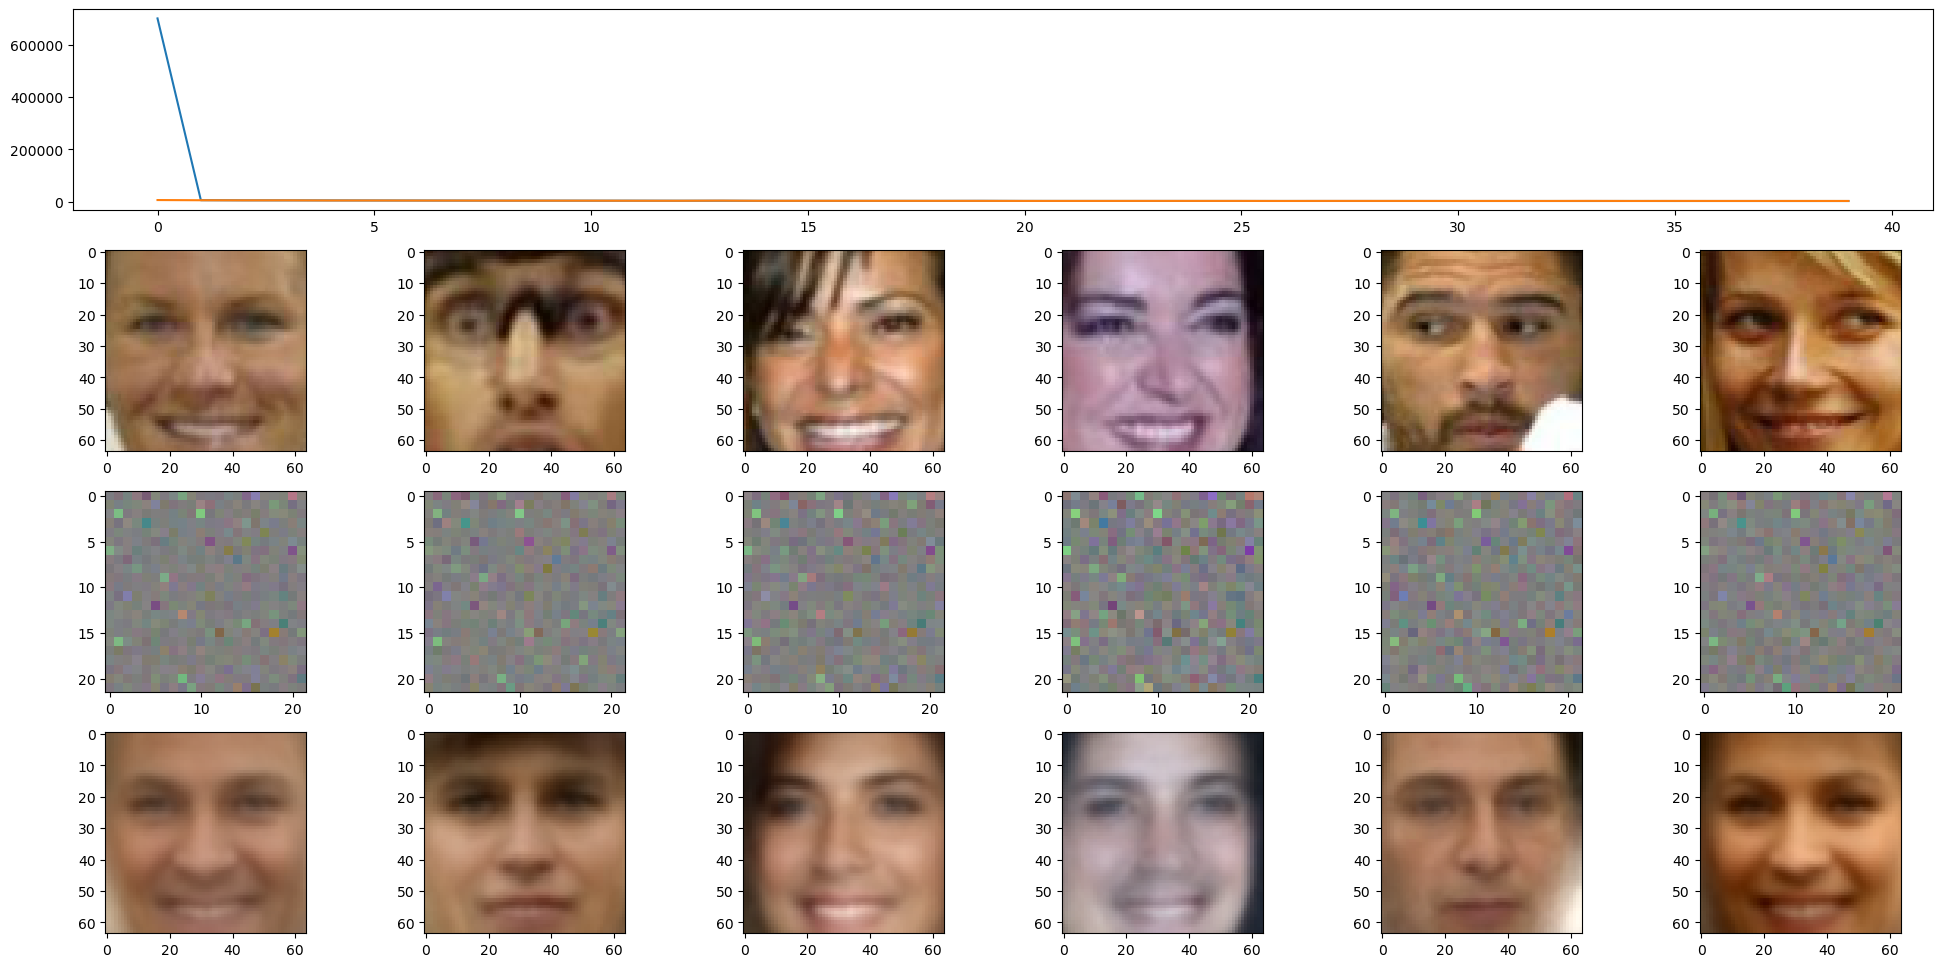

In [84]:
if not PRE_TRAINED1:
    loss_history = train(autoencoder_linear, optimizer, scheduler, criterion, max_epochs, train_data_loader, val_data_loader);
    torch.save(autoencoder_linear.state_dict(), 'autoencoders_linear.pth')
else:
    autoencoder_linear.load_state_dict(torch.load('autoencoder_linear.pth'))

In [87]:
print(loss_history)

([699618.875, 5931.1953125, 5439.75390625, 5276.24853515625, 5106.37841796875, 4870.826171875, 4725.45166015625, 4475.17578125, 4293.57666015625, 4282.76416015625, 4116.70166015625, 4093.4130859375, 3884.91650390625, 3935.072509765625, 3630.90380859375, 3532.55517578125, 3477.50927734375, 3410.609130859375, 3355.6298828125, 3507.947998046875, 3202.650390625, 3122.021484375, 3111.967041015625, 3105.36572265625, 3084.38525390625, 3054.145263671875, 2975.628173828125, 3010.29541015625, 2998.040771484375, 2990.045654296875, 2915.593505859375, 2924.054443359375, 2891.963134765625, 2878.6435546875, 2940.3623046875, 2866.528076171875, 2871.72265625, 2854.22802734375, 2817.556396484375, 2824.167236328125], [6524.39306640625, 5757.7421875, 5357.28759765625, 5337.73583984375, 4839.05859375, 4811.41552734375, 4569.21826171875, 4485.64208984375, 4209.11328125, 4169.28857421875, 4160.46337890625, 3922.40673828125, 3851.537841796875, 4292.52099609375, 3616.5654296875, 3609.81884765625, 3584.67456054

In [102]:
def MSEforConv(y_real, y_pred):
    return nn.MSELoss(reduction='sum')(y_real.view(-1, 3, 64, 64), y_pred)

In [107]:
#del autoencoder_conv
criterion = MSEforConv
autoencoder_conv = AutoencoderConv().to(DEVICE)
optimizer = torch.optim.Adam(autoencoder_conv.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
max_epochs = 40

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Epoch: 40


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


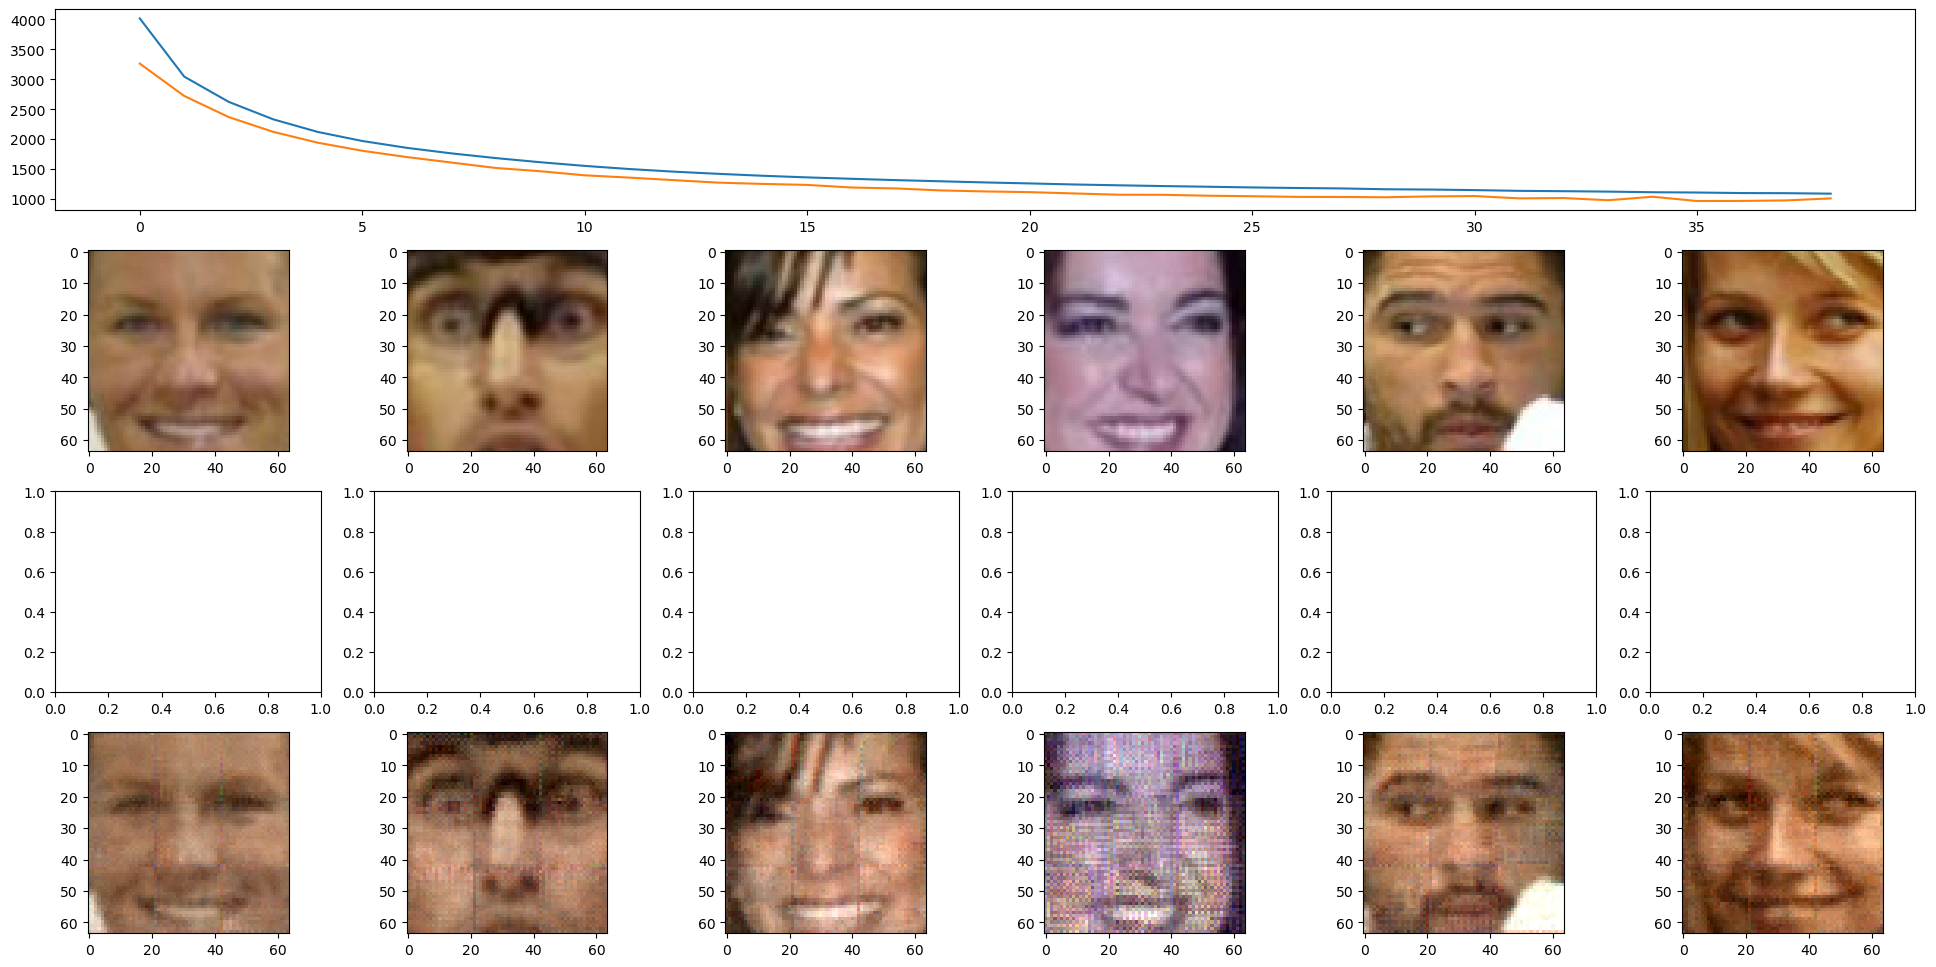

In [108]:
if not PRE_TRAINED1:
    loss_history = train(autoencoder_conv, optimizer, scheduler, criterion, max_epochs, train_data_loader, val_data_loader);
    torch.save(autoencoder_conv.state_dict(), 'autoencoders_conv.pth')
else:
    autoencoder_conv.load_state_dict(torch.load('autoencoders_conv.pth'))

In [110]:
print(loss_history)

([4016.873046875, 3044.88671875, 2623.775390625, 2332.515625, 2122.42919921875, 1971.264892578125, 1856.9671630859375, 1764.791015625, 1685.996826171875, 1616.7923583984375, 1555.5362548828125, 1503.288818359375, 1459.5245361328125, 1423.1424560546875, 1390.940673828125, 1363.5931396484375, 1340.2413330078125, 1318.19091796875, 1298.77294921875, 1279.461181640625, 1263.0364990234375, 1245.4827880859375, 1231.571533203125, 1218.828857421875, 1207.7681884765625, 1196.0828857421875, 1186.733154296875, 1179.58642578125, 1165.7138671875, 1160.8050537109375, 1151.5523681640625, 1139.258056640625, 1133.4052734375, 1126.4373779296875, 1115.976318359375, 1111.1337890625, 1102.32421875, 1100.330322265625, 1092.027587890625], [3262.6142578125, 2722.22509765625, 2370.25732421875, 2123.541748046875, 1942.6285400390625, 1808.1689453125, 1703.048828125, 1611.90185546875, 1521.1536865234375, 1466.489013671875, 1398.5264892578125, 1360.021240234375, 1317.7548828125, 1276.2117919921875, 1254.73571777343

Not bad, right?

## 1.4. Sampling (2 балла)

Давайте теперь будем не просто брать картинку, прогонять ее через автоэекодер и получать реконструкцию, а попробуем создать что-то НОВОЕ

Давайте возьмем и подсунем декодеру какие-нибудь сгенерированные нами векторы (например, из нормального распределения) и посмотрим на результат реконструкции декодера:

__Подсказка:__Е сли вместо лиц у вас выводится непонятно что, попробуйте посмотреть, как выглядят латентные векторы картинок из датасета. Так как в обучении нейронных сетей есть определенная доля рандома, векторы латентного слоя могут быть распределены НЕ как `np.random.randn(25, <latent_space_dim>)`. А чтобы у нас получались лица при запихивании вектора декодеру, вектор должен быть распределен так же, как латентные векторы реальных фоток. Так что в таком случае придется рандом немного подогнать.

In [8]:
def predict(model, data):
    model.eval()
    outputs = []
    latents = []
    for X in data:
        X = torch.Tensor(X).to(DEVICE)
        output, latent = model(X)
        outputs.append(output.to('cpu').detach().numpy())
        latents.append(latent.to('cpu'))
    return outputs, latents

In [137]:
def make_new(model, data, inds=None):
    model.eval()
    outputs = []
    for X in data:
        X = torch.Tensor(X).to(DEVICE)
        if type(model).__name__ == 'AutoencoderLinear':
            output = model.decode(0, X)
        else:
            output = model.decode(inds, X).view(64, 64, 3)
        outputs.append(output.to('cpu').detach().numpy())
    return outputs

In [135]:
def get_mu_sigma(model, data_loader):
    with torch.no_grad():
        all_latent = []
        for X_batch in data_loader:
            if type(model).__name__ == 'AutoencoderLinear':
                _, latent = model.encode(X_batch.to(DEVICE))
            else:
                latent, inds = model.encode(X_batch.to(DEVICE))
            all_latent.append(latent)
        all_latent = torch.cat(all_latent, dim=0)
        if type(model).__name__ == 'AutoencoderLinear':
            return torch.mean(all_latent, dim=0).to('cpu').detach().numpy(), torch.std(all_latent, dim=0).to('cpu').detach().numpy()
        else:
            return torch.mean(all_latent, dim=0).to('cpu').detach().numpy(), torch.std(all_latent, dim=0).to('cpu').detach().numpy(), inds

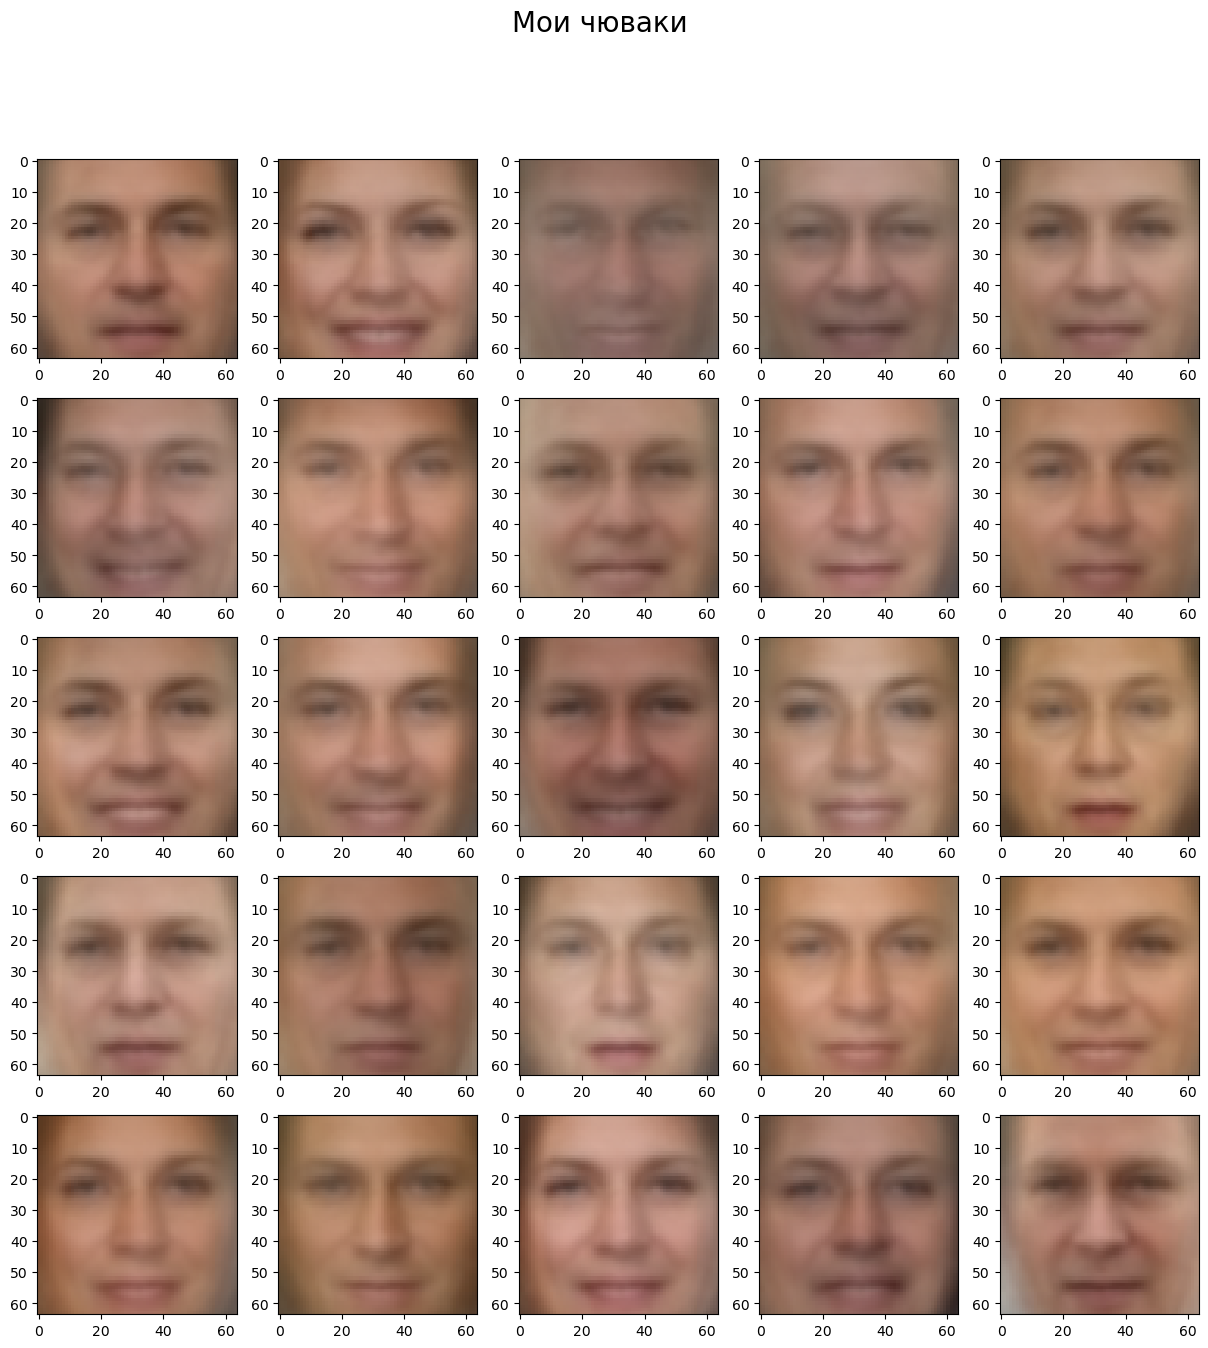

In [92]:
import math

# сгенерируем 25 рандомных векторов размера latent_space
mu, sigma = get_mu_sigma(autoencoder_linear, train_data_loader) #смотрим на распределение латентных векторов тренировочной выборки
z = np.random.normal(loc=mu, scale=sigma, size=(25, math.prod(dim_code))) #чтобы их параметры использовать при генерации новых объектов
output = make_new(autoencoder_linear, z)
fig, axes = plt.subplots(figsize=[3 * 5, 3 * 5], nrows=5, ncols=5)
axes = axes.flatten()
for i in range(len(output)):
    axes[i].imshow(output[i])
fig.suptitle('Мои чюваки', fontsize=20)
plt.show()

Давайте теперь то же самое попробуем, но уже с конволюцинной сетью. Но это будет плохо, потому что я похоже тупанул. Надо было делать сеть с conv и unconv, так как последний не требует индексов в отличии от maxpool2d, который их требует. Мне из-за этого пришлось давать эти самые индексы, взятые вообще после encode рандомной картинки. Но сейчас мне переделывать лень.

In [122]:
autoencoder_conv = AutoencoderConv().to(DEVICE)
autoencoder_conv.load_state_dict(torch.load('autoencoders_conv.pth'))

<All keys matched successfully>

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

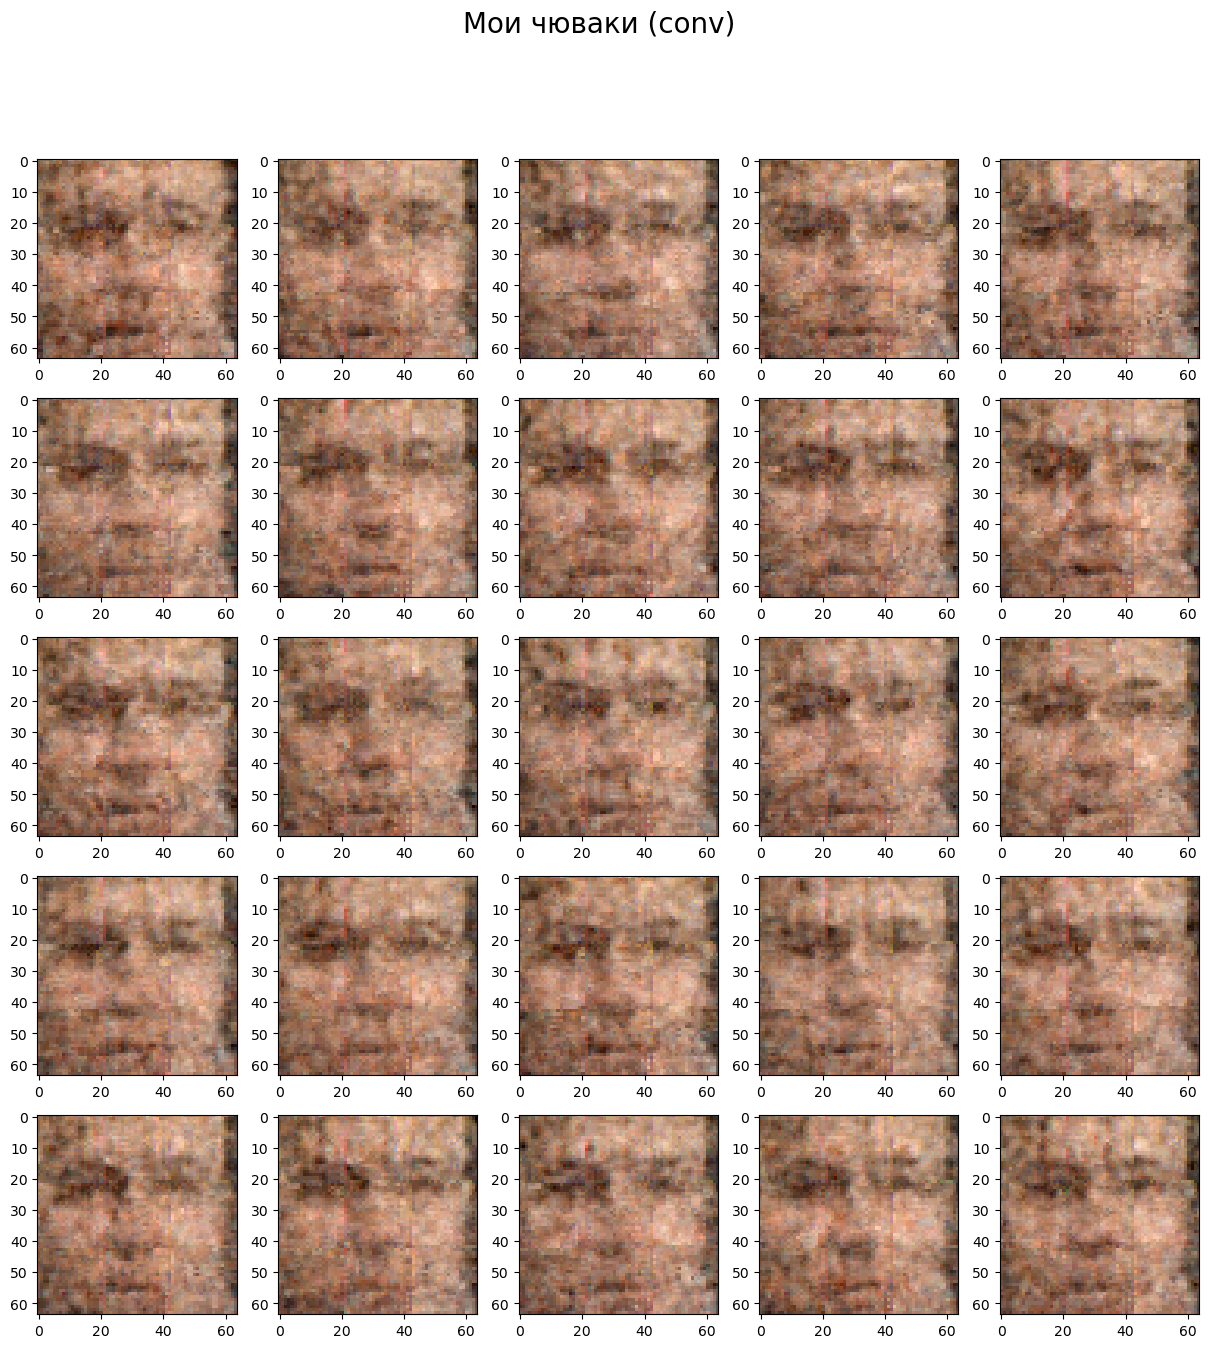

In [149]:
# сгенерируем 25 рандомных векторов размера latent_space
mu, sigma, inds = get_mu_sigma(autoencoder_conv, train_data_loader) #смотрим на распределение латентных векторов тренировочной выборки
z = np.random.normal(loc=mu, scale=sigma, size=(25, 1, 64, 8, 8)) #чтобы их параметры использовать при генерации новых объектов
output = make_new(autoencoder_conv, z, [inds[0][0].view(-1, 16, 32, 32), inds[1][0].view(-1, 32, 16, 16), inds[2][0].view(-1, 64, 8, 8)])
fig, axes = plt.subplots(figsize=[3 * 5, 3 * 5], nrows=5, ncols=5)
axes = axes.flatten()
for i in range(len(output)):
    axes[i].imshow(output[i])
fig.suptitle('Мои чюваки (conv)', fontsize=20)
plt.show()

## 1.5 Time to make fun! (3 балла)

Давайте научимся пририсовывать людям улыбки =)

<img src="https://i.imgur.com/tOE9rDK.png" alt="linear" width="700" height="400">

План такой:

1. Нужно выделить "вектор улыбки": для этого нужно из выборки изображений найти несколько (~15) людей с улыбками и столько же без.

Найти людей с улыбками вам поможет файл с описанием датасета, скачанный вместе с датасетом. В нем указаны имена картинок и присутствубщие атрибуты (улыбки, очки...)

2. Вычислить латентный вектор для всех улыбающихся людей (прогнать их через encoder) и то же для всех грустненьких

3. Вычислить, собственно, вектор улыбки -- посчитать разность между средним латентным вектором улыбающихся людей и средним латентным вектором грустных людей

4. А теперь приделаем улыбку грустному человеку: добавим полученный в пункте 3 вектор к латентному вектору грустного человека и прогоним полученный вектор через decoder. Получим того же человека, но уже не грустненького!

Убедимся, что большое значение в столбце Smiling означает улыбку, а маленькое наоборот.

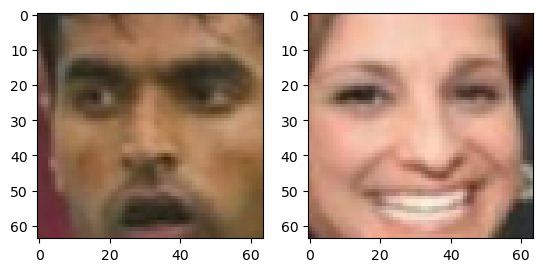

In [93]:
max_smile_arg = attrs['Smiling'].argmax()
min_smile_arg = attrs['Smiling'].argmin()
plt.subplot(1, 2, 1)
plt.imshow(data[min_smile_arg])
plt.subplot(1, 2, 2)
plt.imshow(data[max_smile_arg])
plt.show()

В отсортированном столбце Smiling возьмем первые 15 и последние 15 строк - грустных и весёлых, и будем работать с ними далее.

In [94]:
sorted_arg_smiles = attrs['Smiling'].argsort()
sad_data = data[sorted_arg_smiles[:15]]
happy_data = data[sorted_arg_smiles[-15:]]

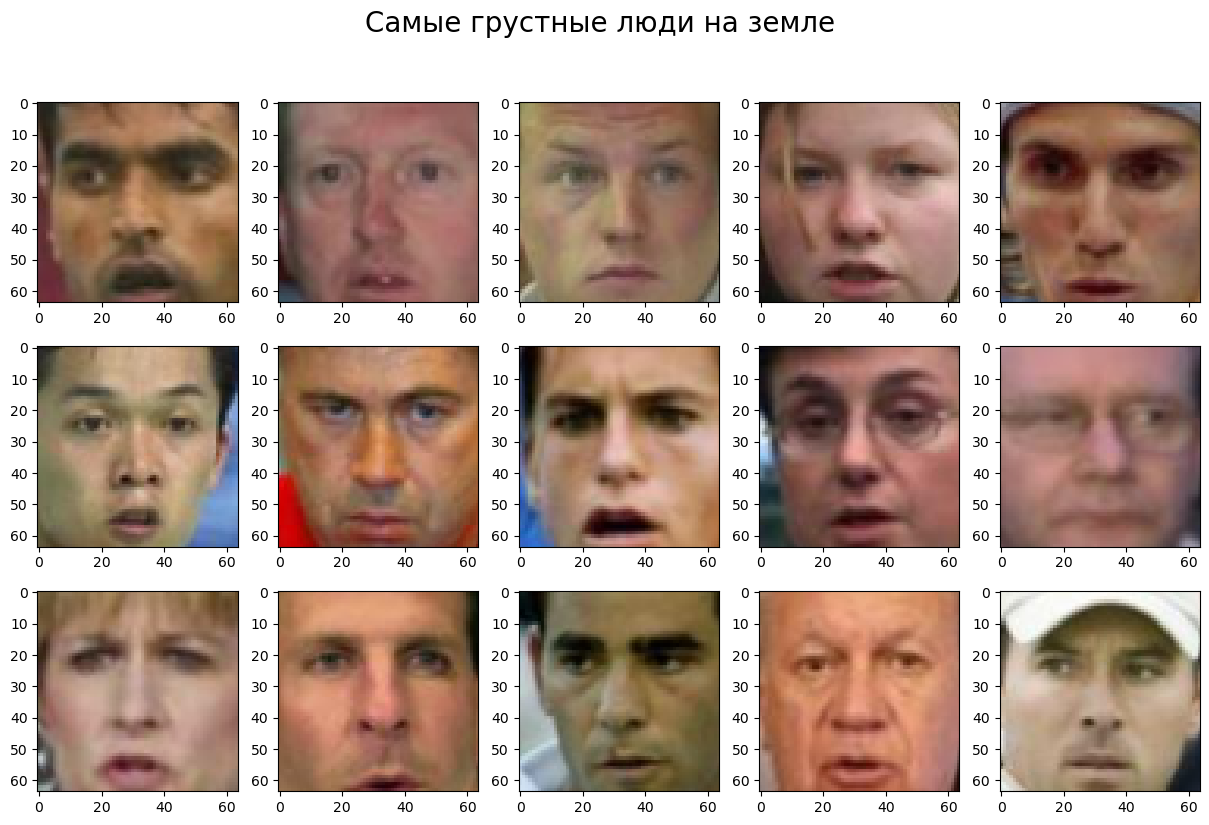

In [95]:
plt.figure(figsize=[3*5, 3*3])
for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(sad_data[i])
plt.suptitle('Самые грустные люди на земле', fontsize=20)
plt.show()

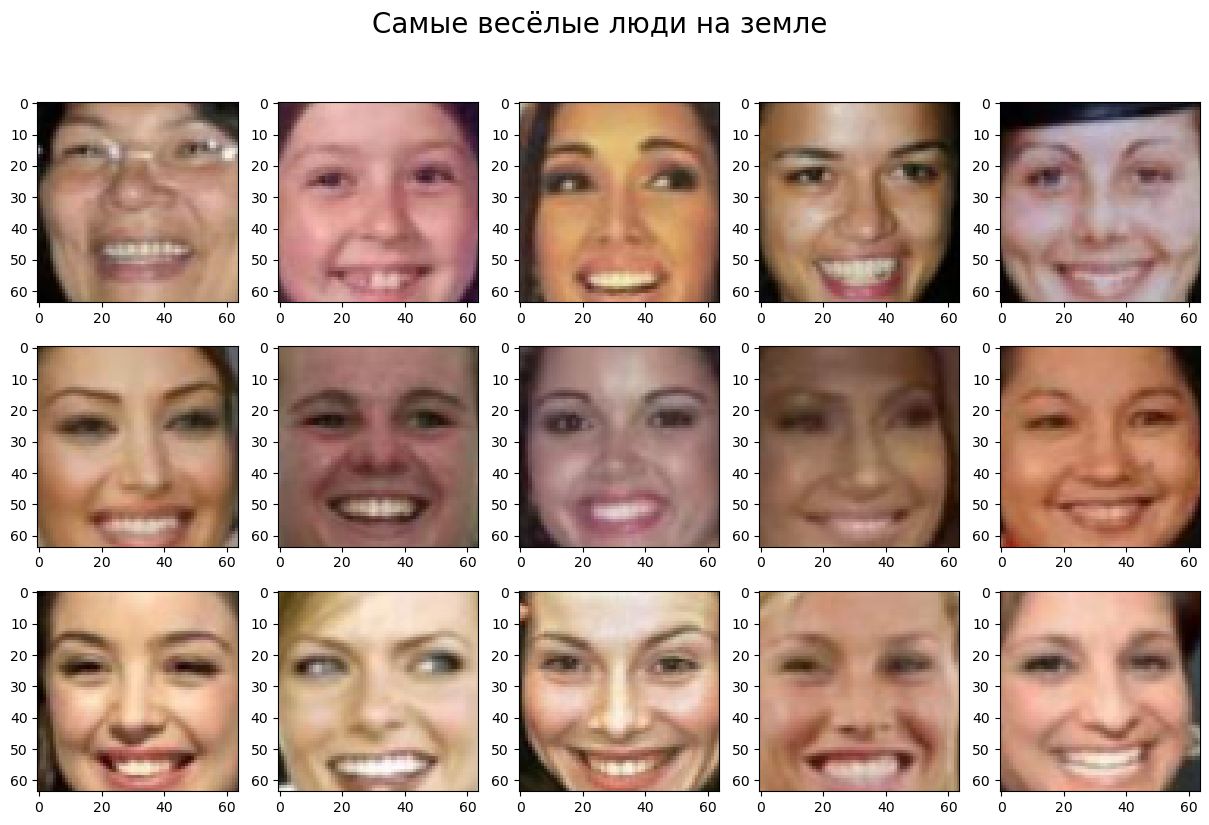

In [96]:
plt.figure(figsize=[3*5, 3*3])
for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(happy_data[i])
plt.suptitle('Самые весёлые люди на земле', fontsize=20)
plt.show()

In [11]:
def make_them_happy(model, sad_data, happy_data):
    with torch.no_grad():
        sad_mean_latent = model.encode(sad_data).mean(dim=0)
        happy_mean_latent = model.encode(happy_data).mean(dim=0)
        smile_latent = happy_mean_latent - sad_mean_latent
        return model.decode(model.encode(sad_data) + smile_latent).to('cpu').detach().numpy()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


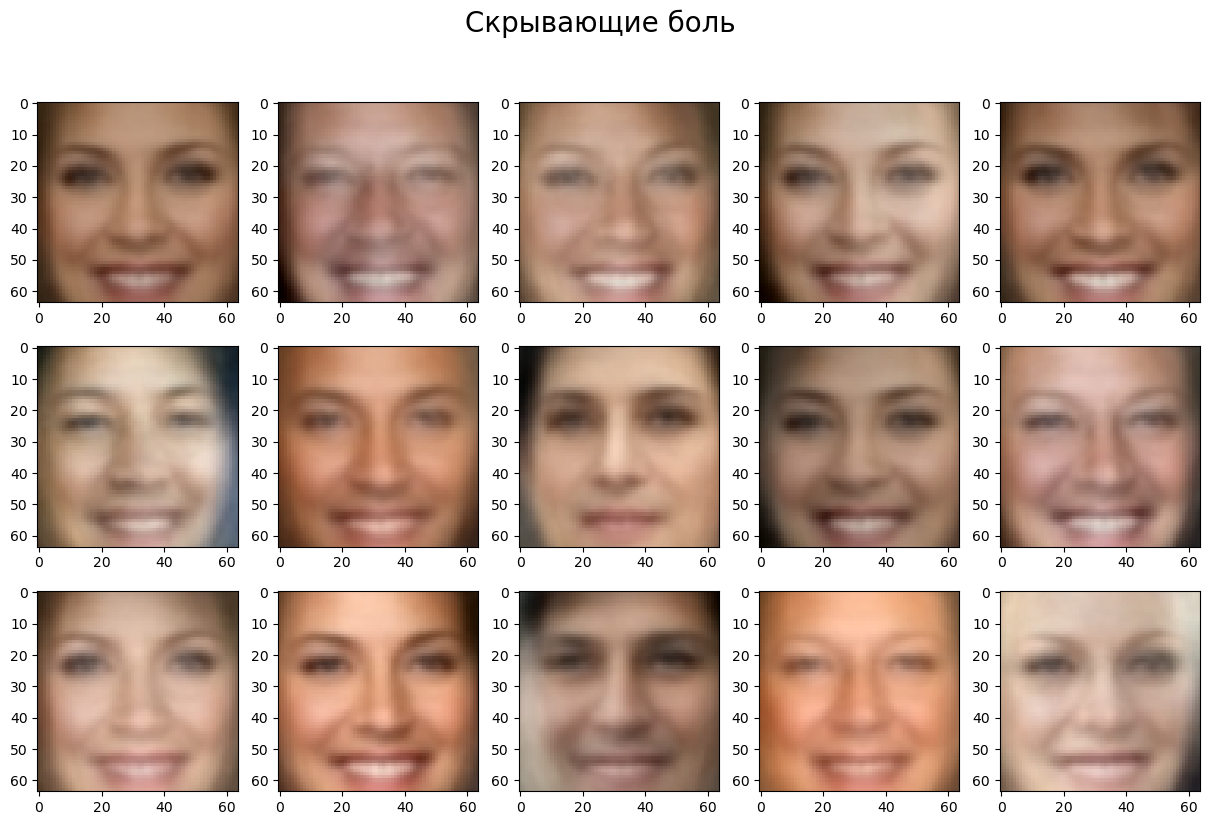

In [97]:
sad_data = torch.Tensor(sad_data).to(DEVICE)
happy_data = torch.Tensor(happy_data).to(DEVICE)

sad_to_smile = make_them_happy(autoencoder_linear, sad_data, happy_data)

plt.figure(figsize=[3*5, 3*3])
for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(sad_to_smile[i])
plt.suptitle('Скрывающие боль (linear)', fontsize=20)
plt.show()

In [ ]:
#sad_data = torch.Tensor(sad_data).to(DEVICE)
#happy_data = torch.Tensor(happy_data).to(DEVICE)

sad_to_smile = make_them_happy(autoencoder_conv, sad_data, happy_data)

plt.figure(figsize=[3*5, 3*3])
for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(sad_to_smile[i])
plt.suptitle('Скрывающие боль (conv)', fontsize=20)
plt.show()

Вуаля! Вы восхитительны!

Теперь вы можете пририсовывать людям не только улыбки, но и много чего другого -- закрывать/открывать глаза, пририсовывать очки... в общем, все, на что хватит фантазии и на что есть атрибуты в `all_attrs`:)

# Часть 2: Variational Autoencoder (10 баллов)

Займемся обучением вариационных автоэнкодеров — проапгрейженной версии AE. Обучать будем на датасете MNIST, содержащем написанные от руки цифры от 0 до 9

In [1]:
import numpy as np
from torch.autograd import Variable
from torchvision import datasets
from torchvision import transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data_utils
import torch
import matplotlib.pyplot as plt

import os
import pandas as pd
import skimage.io
from skimage.transform import resize


%matplotlib inline

from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

In [2]:
batch_size = 32
# MNIST Dataset
mnist_root = '/Users/dantesto/Documents/Jupiter Nootebooks/MNIST recognition/'
mnist_train_dataset = datasets.MNIST(root=mnist_root, train=True, transform=transforms.ToTensor(), download=False)
mnist_test_dataset = datasets.MNIST(root=mnist_root, train=False, transform=transforms.ToTensor(), download=False)

# Data Loader (Input Pipeline)
mnist_train_loader = DataLoader(dataset=mnist_train_dataset, batch_size=batch_size, shuffle=True)
mnist_val_loader = DataLoader(dataset=mnist_test_dataset, batch_size=batch_size, shuffle=False)

## 2.1 Архитектура модели и обучение (2 балла)

Реализуем VAE. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Рекомендуем пользоваться более сложными моделями, чем та, что была на семинаре:) Экспериментируйте!

In [3]:
class VAE_linear(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(28*28, 392),
            nn.ReLU(),
            nn.Linear(392, 196),
            nn.ReLU(),
            nn.Linear(196, 98)
        )
        self.linear_mu = nn.Linear(98, 49)
        self.linear_logsigma = nn.Linear(98, 49)
        self.decoder = nn.Sequential(
            nn.Linear(49, 196), #здесь in=49=98/2, так как после гауссовского сэмплера я получу вектор вдвое меньший
            nn.ReLU(),
            nn.Linear(196, 392),
            nn.ReLU(),
            nn.Linear(392, 28*28),
        )

    def encode(self, x):
        first_flatten_dim = 1 if len(x.size()) == 4 else 0
        x = nn.Flatten(first_flatten_dim, -1)(x)
        x = self.encoder(x)
        mu = self.linear_mu(x)
        logsigma = self.linear_logsigma(x)
        return first_flatten_dim, mu, logsigma

    def gaussian_sampler(self, mu, logsigma):
        if self.training:
            sigma = torch.exp(logsigma * 0.5)
            eps = torch.randn_like(sigma)
            z = mu + sigma * eps
            return z
        else:
            # на инференсе возвращаем не случайный вектор из нормального распределения, а центральный -- mu.
            # на инференсе выход автоэнкодера должен быть детерминирован.
            return mu

    def decode(self, first_flatten_dim, latent_code):
        reconstruction = self.decoder(latent_code)
        return nn.Unflatten(first_flatten_dim, (1, 28, 28))(reconstruction)

    def forward(self, x):
        first_flatten_dim, mu, logsigma = self.encode(x)
        latent_vector = self.gaussian_sampler(mu, logsigma)
        reconstruction = self.decode(first_flatten_dim, latent_vector)
        return reconstruction, mu, logsigma

Скопирую код обучения, потому что лучше я там переделаю строчки под датасет с двумя объектами, чем даталоадер.

In [14]:
from IPython.display import clear_output

def train2(model, opt, scheduler, loss_fn, epochs, data_tr, data_val):
    train_loss_history, val_loss_history = [], []
    val_batch = next(iter(data_val))[0]

    for epoch in range(epochs):
        model.train()
        avg_loss = 0
        for X_batch, y_batch in data_tr:
            X_batch = X_batch.to(DEVICE)
            opt.zero_grad()
            output, mu, logsigma = model(X_batch)
            loss = loss_fn(X_batch, mu, logsigma, output)
            loss.backward()
            opt.step()
            avg_loss += loss
        avg_loss /= len(data_tr)
        if epoch != 0:
            train_loss_history.append(avg_loss.item())

        model.eval()
        avg_loss = 0
        for X_batch, y_batch in data_val:
            X_batch = X_batch.to(DEVICE)
            output, mu, logsigma = model(X_batch)
            loss = loss_fn(X_batch, mu, logsigma, output)
            avg_loss += loss
        avg_loss /= len(data_val)
        if epoch != 0:
            val_loss_history.append(avg_loss.item())

        clear_output(wait=True)
        print('Epoch:', epoch+1)
        plt.figure(figsize=[4 * 6, 3 * 4])
        if epoch != 0:
            plt.subplot(4, 1, 1)
            plt.plot(train_loss_history)
            plt.plot(val_loss_history)
        output1 = []
        for i in range(6):
            output, _, _ = model(val_batch[i].to(DEVICE))
            if type(model).__name__ == 'VAE_linear':
                output1.append(output.to('cpu').detach().numpy())
            #else:
            #    output1.append(output.view(64, 64, 3).to('cpu').detach().numpy())
            #output1.append(output.view(64, 64, 3).to('cpu').detach().numpy())
        for i in range(6):
            plt.subplot(4, 6, 1 * 6 + i + 1)
            plt.imshow(val_batch[i].reshape(28, 28))
        for i in range(6):
            plt.subplot(4, 6, 2 * 6 + i + 1)
            plt.imshow(output1[i].reshape(28, 28))
        plt.show()
    return train_loss_history, val_loss_history

Определим лосс и его компоненты для VAE:

Надеюсь, вы уже прочитали материал в towardsdatascience (или еще где-то) про VAE и знаете, что лосс у VAE состоит из двух частей: KL и log-likelihood.

Общий лосс будет выглядеть так:

$$\mathcal{L} = -D_{KL}(q_{\phi}(z|x)||p(z)) + \log p_{\theta}(x|z)$$

Формула для KL-дивергенции:

$$D_{KL} = -\frac{1}{2}\sum_{i=1}^{dimZ}(1+log(\sigma_i^2)-\mu_i^2-\sigma_i^2)$$

В качестве log-likelihood возьмем привычную нам кросс-энтропию.

In [5]:
def KL_divergence(mu, logsigma):
    """
    часть функции потерь, которая отвечает за "близость" латентных представлений разных людей
    """
    loss = -0.5 * torch.sum(1 + logsigma - mu.pow(2) - logsigma.exp())
    return loss

def log_likelihood(x, reconstruction):
    """
    часть функции потерь, которая отвечает за качество реконструкции (как mse в обычном autoencoder)
    """
    loss = nn.BCEWithLogitsLoss(reduction='sum')
    return loss(reconstruction, x)

def loss_vae(x, mu, logsigma, reconstruction):
    return KL_divergence(mu, logsigma) + log_likelihood(x, reconstruction) #здесь минус должен быть перед KL?

И обучим модель:

In [6]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(DEVICE)

cuda


In [16]:
import gc
vautoencoder_linear = vautoencoder_linear.to('cpu')
del vautoencoder_linear
torch.cuda.empty_cache()
gc.collect()

criterion = loss_vae
vautoencoder_linear = VAE_linear().to(DEVICE)
optimizer = torch.optim.Adam(vautoencoder_linear.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
max_epochs = 40

Epoch: 40


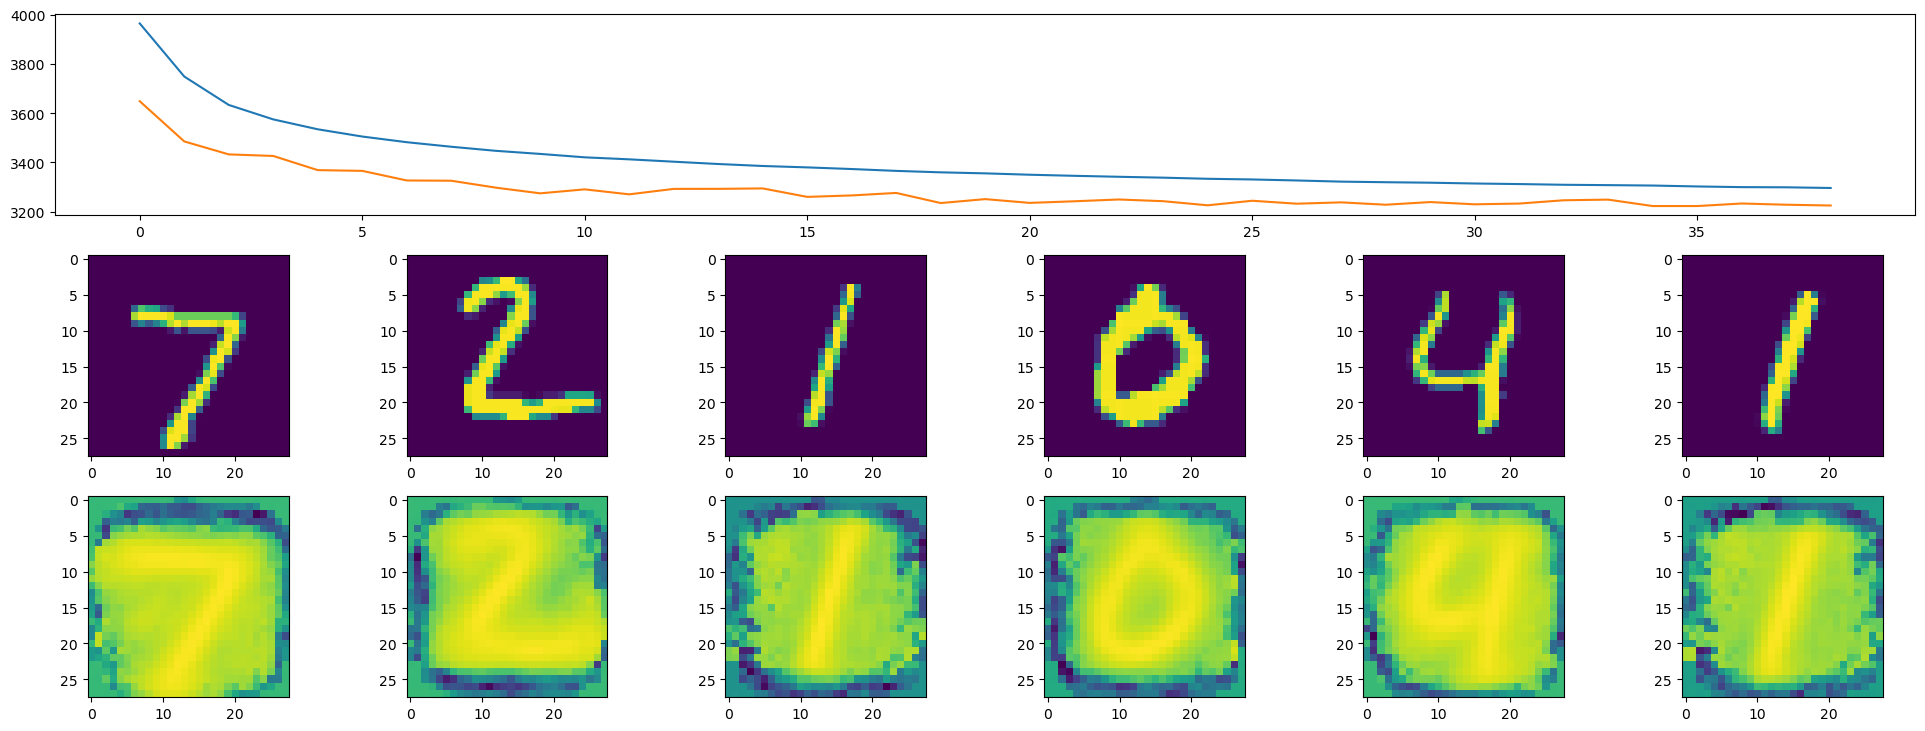

In [17]:
loss_history = train2(vautoencoder_linear, optimizer, scheduler, criterion, max_epochs, mnist_train_loader, mnist_val_loader);

In [18]:
torch.save(vautoencoder_linear.state_dict(), 'vautoencoder_linear.pth')

Давайте посмотрим, как наш тренированный VAE кодирует и восстанавливает картинки: (в процессе обучения выводит)

Давайте попробуем проделать для VAE то же, что и с обычным автоэнкодером -- подсунуть decoder'у из VAE случайные векторы из нормального распределения и посмотреть, какие картинки получаются:

In [25]:
def make_new2(model, data):
    model.eval()
    outputs = []
    for X in data:
        X = torch.Tensor(X).to(DEVICE)
        output = model.decode(0, X)
        outputs.append(output.to('cpu').detach().numpy())
    return outputs

In [26]:
def get_mu_sigma2(model, data_loader):
    with torch.no_grad():
        all_latent = []
        for X_batch, y_batch in data_loader:
            _, mu, logsigma = model.encode(X_batch.to(DEVICE))
            latent = model.gaussian_sampler(mu, logsigma)
            all_latent.append(latent)
        all_latent = torch.cat(all_latent, dim=0)
        return torch.mean(all_latent, dim=0).to('cpu').detach().numpy(), torch.std(all_latent, dim=0).to('cpu').detach().numpy()

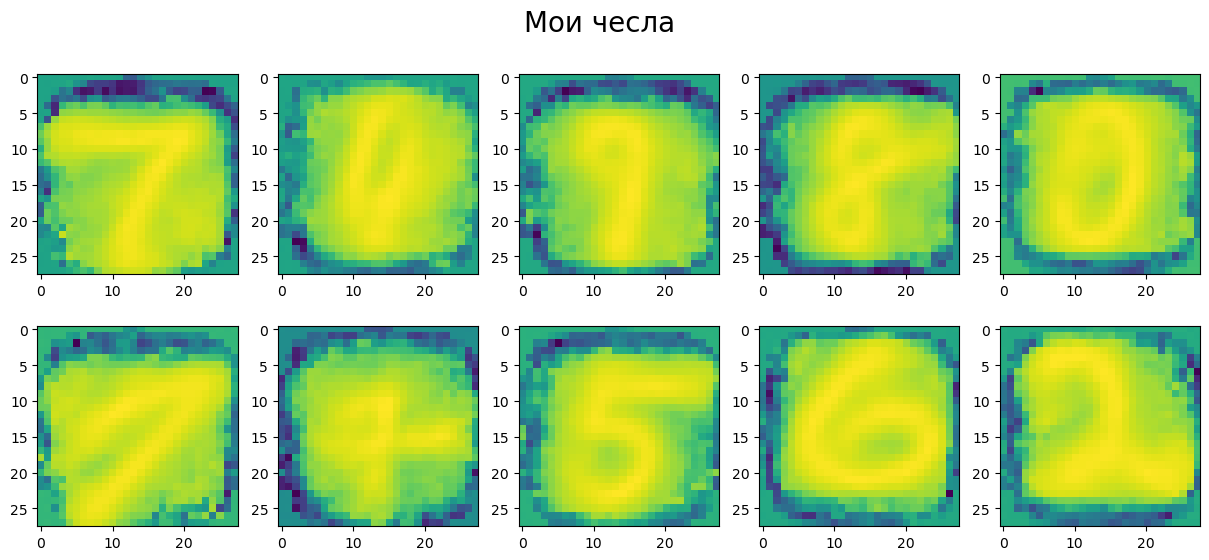

In [28]:
# вспомните про замечание из этого же пункта обычного AE про распределение латентных переменных
mu, sigma = get_mu_sigma2(vautoencoder_linear, mnist_train_loader)
z = np.array([np.random.normal(mu, sigma, 49) for i in range(10)])
output = make_new2(vautoencoder_linear, z)
fig, axes = plt.subplots(figsize=[3 * 5, 3 * 2], nrows=2, ncols=5)
axes = axes.flatten()
for i in range(len(output)):
    axes[i].imshow(output[i].reshape(28, 28))
fig.suptitle('Мои чесла', fontsize=20)
plt.show()

## 2.2. Latent Representation (2 балла)

Давайте посмотрим, как латентные векторы картинок лиц выглядят в пространстве.
Ваша задача -- изобразить латентные векторы картинок точками в двумерном просторанстве.

Это позволит оценить, насколько плотно распределены латентные векторы изображений цифр в пространстве.

Плюс давайте сделаем такую вещь: покрасим точки, которые соответствуют картинкам каждой цифры, в свой отдельный цвет

Подсказка: красить -- это просто =) У plt.scatter есть параметр c (color), см. в документации.


Итак, план:
1. Получить латентные представления картинок тестового датасета
2. С помощтю `TSNE` (есть в `sklearn`) сжать эти представления до размерности 2 (чтобы можно было их визуализировать точками в пространстве)
3. Визуализировать полученные двумерные представления с помощью `matplotlib.scatter`, покрасить разными цветами точки, соответствующие картинкам разных цифр.

In [31]:
def get_latent_code(model, data_loader):
    model.eval()
    all_latent = []
    all_nums = []
    for X_batch, y_batch in data_loader:
        _, mu, logsigma = model.encode(X_batch.to(DEVICE))
        latent = model.gaussian_sampler(mu, logsigma)
        all_latent.append(latent)
        all_nums.append(y_batch)
    all_latent = torch.cat(all_latent, dim=0).to('cpu').detach().numpy()
    all_nums = torch.cat(all_nums, dim=0).to('cpu').detach().numpy()
    return all_latent, all_nums

In [ ]:
from sklearn.manifold import TSNE

latents, nums = get_latent_code(vautoencoder_linear, mnist_train_loader)
latents2d = TSNE(n_components=2, learning_rate='auto', init='random', perplexity=3).fit_transform(latents);

In [ ]:
color_dict = {} #словарь, где color_dict[i] - это список координат x числа i, и второй список координат y
for i in range(10):
    color_dict[i] = [], []
for i, num in enumerate(nums):
    color_dict[num][0].append(latents2d[i][0])
    color_dict[num][1].append(latents2d[i][1])

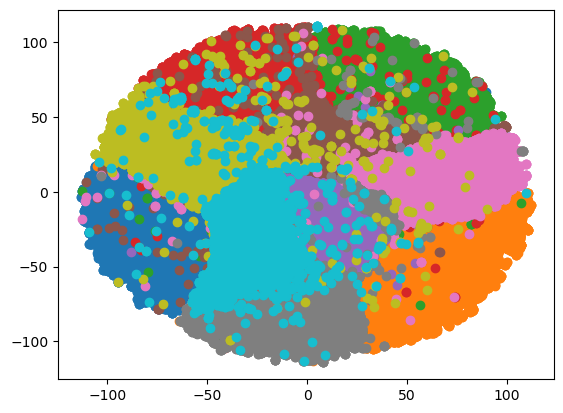

In [33]:
for i in range(10):
    plt.scatter(color_dict[i][0], color_dict[i][1])
plt.show()

Что вы думаете о виде латентного представления?
Ну в приципе отдельно находятся, но шумы есть тоже

__Congrats v2.0!__

## 2.3. Conditional VAE (6 баллов)


Мы уже научились обучать обычный AE на датасете картинок и получать новые картинки, используя генерацию шума и декодер.
Давайте теперь допустим, что мы обучили AE на датасете MNIST и теперь хотим генерировать новые картинки с числами с помощью декодера (как выше мы генерили рандомные лица).
И вот нам понадобилось сгенерировать цифру 8, и мы подставляем разные варианты шума, но восьмерка никак не генерится:(

Хотелось бы добавить к нашему AE функцию "выдай мне рандомное число из вот этого вот класса", где классов десять (цифры от 0 до 9 образуют десять классов).  Conditional AE — так называется вид автоэнкодера, который предоставляет такую возможность. Ну, название "conditional" уже говорит само за себя.

И в этой части задания мы научимся такие обучать.

### Архитектура

На картинке ниже представлена архитектура простого Conditional VAE.

По сути, единственное отличие от обычного -- это то, что мы вместе с картинкой в первом слое энкодера и декодера передаем еще информацию о классе картинки.

То есть, в первый (входной) слой энкодера подается конкатенация картинки и информации о классе (например, вектора из девяти нулей и одной единицы). В первый слой декодера подается конкатенация латентного вектора и информации о классе.


![alt text](https://sun9-63.userapi.com/impg/Mh1akf7mfpNoprrSWsPOouazSmTPMazYYF49Tw/djoHNw_9KVA.jpg?size=1175x642&quality=96&sign=e88baec5f9bb91c8443fba31dcf0a4df&type=album)

![alt text](https://sun9-73.userapi.com/impg/UDuloLNKhzTBYAKewgxke5-YPsAKyGOqA-qCRg/MnyCavJidxM.jpg?size=1229x651&quality=96&sign=f2d21bfacc1c5755b76868dc4cfef39c&type=album)



На всякий случай: это VAE, то есть, latent у него все еще состоит из mu и sigma

Таким образом, при генерации новой рандомной картинки мы должны будем передать декодеру сконкатенированные латентный вектор и класс картинки.

P.S. Также можно передавать класс картинки не только в первый слой, но и в каждый слой сети. То есть на каждом слое конкатенировать выход из предыдущего слоя и информацию о классе.

In [84]:
class_num = 10

class CVAE_linear(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(28*28 + class_num, 392), #+10 - это количество классов
            nn.ReLU(),
            nn.Linear(392, 196),
            nn.ReLU(),
            nn.Linear(196, 98)
        )
        self.linear_mu = nn.Linear(98, 49)
        self.linear_logsigma = nn.Linear(98, 49)
        self.decoder = nn.Sequential(
            nn.Linear(49 + class_num, 196),
            nn.ReLU(),
            nn.Linear(196, 392),
            nn.ReLU(),
            nn.Linear(392, 28*28) #выход не должен восстанавливать информацию о таргете класса, поэтому нет '+ class_num'
        )

    def encode(self, x, c):
        first_flatten_dim = 1 if len(x.size()) == 4 else 0
        x = nn.Flatten(first_flatten_dim, -1)(x)
        x = torch.cat([x, c], dim=first_flatten_dim)
        x = self.encoder(x)
        mu = self.linear_mu(x)
        logsigma = self.linear_logsigma(x)
        return first_flatten_dim, mu, logsigma

    def gaussian_sampler(self, mu, logsigma):
        if self.training:
            sigma = torch.exp(logsigma * 0.5)
            eps = torch.randn_like(sigma)
            z = mu + sigma * eps
            return z
        else:
            # на инференсе возвращаем не случайный вектор из нормального распределения, а центральный -- mu.
            # на инференсе выход автоэнкодера должен быть детерминирован.
            return mu

    def decode(self, first_flatten_dim, latent_code, c):
        latent_code = torch.cat([latent_code, c], dim=first_flatten_dim)
        reconstruction = self.decoder(latent_code)
        return nn.Unflatten(first_flatten_dim, (1, 28, 28))(reconstruction)

    def forward(self, x, c):
        first_flatten_dim, mu, logsigma = self.encode(x, c)
        latent_vector = self.gaussian_sampler(mu, logsigma)
        reconstruction = self.decode(first_flatten_dim, latent_vector, c)
        return reconstruction, mu, logsigma

In [52]:
ohe_dict = {} #подготовительный словарь для ohe. ohe_dict[3] = [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
for i in range(10):
    ohe_dict[i] = [0] * 10
    ohe_dict[i][i] = 1
    ohe_dict[i] = torch.Tensor(ohe_dict[i])

In [53]:
#получаем one_hot_encoding от чисел
def get_ohed_nums(y_batch):
    ohed_nums = [ohe_dict[y.item()] for y in y_batch]
    return torch.stack(ohed_nums)

In [90]:
from IPython.display import clear_output

def train3(model, opt, scheduler, loss_fn, epochs, data_tr, data_val):
    train_loss_history, val_loss_history = [], []
    val_batch = next(iter(data_val))
    val_batch_ohed_y = get_ohed_nums(val_batch[1]).to(DEVICE)
    val_batch = val_batch[0]

    for epoch in range(epochs):
        model.train()
        avg_loss = 0
        for X_batch, y_batch in data_tr:
            X_batch = X_batch.to(DEVICE)
            opt.zero_grad()
            output, mu, logsigma = model(X_batch, get_ohed_nums(y_batch).to(DEVICE))
            loss = loss_fn(X_batch, mu, logsigma, output)
            loss.backward()
            opt.step()
            avg_loss += loss
        avg_loss /= len(data_tr)
        if epoch != 0:
            train_loss_history.append(avg_loss.item())

        model.eval()
        avg_loss = 0
        for X_batch, y_batch in data_val:
            X_batch = X_batch.to(DEVICE)
            output, mu, logsigma = model(X_batch, get_ohed_nums(y_batch).to(DEVICE))
            loss = loss_fn(X_batch, mu, logsigma, output)
            avg_loss += loss
        avg_loss /= len(data_val)
        if epoch != 0:
            val_loss_history.append(avg_loss.item())

        clear_output(wait=True)
        print('Epoch:', epoch+1)
        plt.figure(figsize=[4 * 6, 3 * 4])
        if epoch != 0:
            plt.subplot(4, 1, 1)
            plt.plot(train_loss_history)
            plt.plot(val_loss_history)
        output1 = []
        for i in range(6):
            output, _, _ = model(val_batch[i].to(DEVICE), val_batch_ohed_y[i])
            if type(model).__name__ == 'CVAE_linear':
                output1.append(output.to('cpu').detach().numpy())
            #else:
            #    output1.append(output.view(64, 64, 3).to('cpu').detach().numpy())
            #output1.append(output.view(64, 64, 3).to('cpu').detach().numpy())
        for i in range(6):
            plt.subplot(4, 6, 1 * 6 + i + 1)
            plt.imshow(val_batch[i].reshape(28, 28))
        for i in range(6):
            plt.subplot(4, 6, 2 * 6 + i + 1)
            plt.imshow(output1[i].reshape(28, 28))
        plt.show()
    return train_loss_history, val_loss_history

In [91]:
import gc
cvautoencoder_linear = cvautoencoder_linear.to('cpu')
del cvautoencoder_linear
torch.cuda.empty_cache()
gc.collect()

criterion = loss_vae
cvautoencoder_linear = CVAE_linear().to(DEVICE)
optimizer = torch.optim.Adam(cvautoencoder_linear.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
max_epochs = 40

Epoch: 40


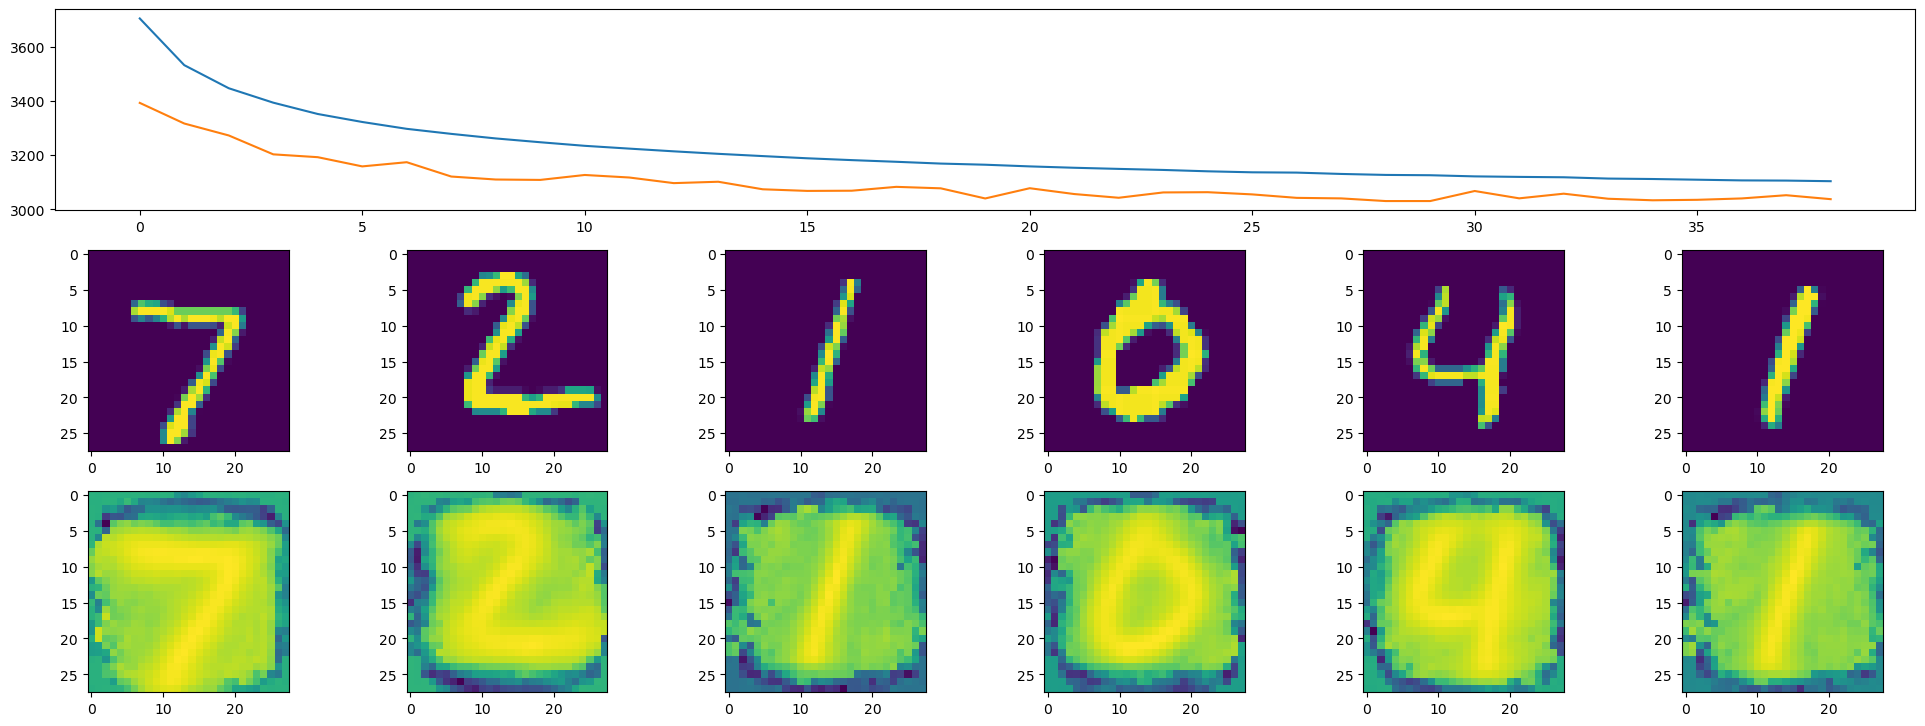

In [92]:
loss_history = train3(cvautoencoder_linear, optimizer, scheduler, criterion, max_epochs, mnist_train_loader, mnist_val_loader);

In [93]:
torch.save(cvautoencoder_linear.state_dict(), 'cvautoencoder_linear.pth')

### Sampling


Тут мы будем сэмплировать из CVAE. Это прикольнее, чем сэмплировать из простого AE/VAE: тут можно взять один и тот же латентный вектор и попросить CVAE восстановить из него картинки разных классов!
Для MNIST вы можете попросить CVAE восстановить из одного латентного вектора, например, картинки цифры 5 и 7.

In [106]:
def make_new3(model, data, nums):
    model.eval()
    outputs = []
    ohed_nums = get_ohed_nums(torch.Tensor(nums)).to(DEVICE)
    for i in range(len(nums)):
        for X in data:
            X = torch.Tensor(X).to(DEVICE)
            y = ohed_nums[i]
            output = model.decode(0, X, y)
            outputs.append(output.to('cpu').detach().numpy())
    return outputs

In [107]:
def get_mu_sigma3(model, data_loader):
    with torch.no_grad():
        all_latent = []
        for X_batch, y_batch in data_loader:
            _, mu, logsigma = model.encode(X_batch.to(DEVICE), get_ohed_nums(y_batch).to(DEVICE))
            latent = model.gaussian_sampler(mu, logsigma)
            all_latent.append(latent)
        all_latent = torch.cat(all_latent, dim=0)
        return torch.mean(all_latent, dim=0).to('cpu').detach().numpy(), torch.std(all_latent, dim=0).to('cpu').detach().numpy()

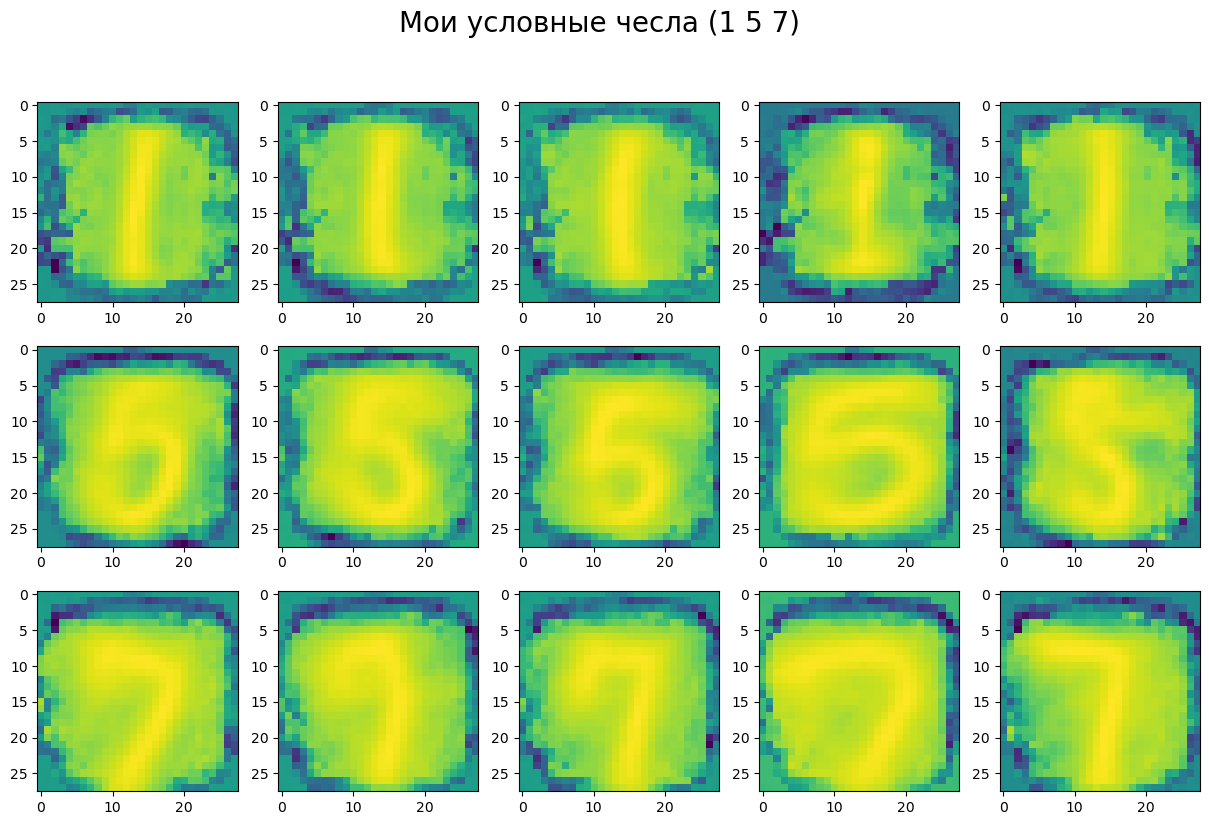

In [112]:
# вспомните про замечание из этого же пункта обычного AE про распределение латентных переменных
mu, sigma = get_mu_sigma3(cvautoencoder_linear, mnist_train_loader)
z = np.array([np.random.normal(mu, sigma, 49) for i in range(5)])
nums = [1, 5, 7]
output = make_new3(cvautoencoder_linear, z, nums)
fig, axes = plt.subplots(figsize=[3 * 5, 3 * 3], nrows=3, ncols=5)
axes = axes.flatten()
for i in range(len(output)):
    axes[i].imshow(output[i].reshape(28, 28))
fig.suptitle('Мои условные чесла (1 5 7)', fontsize=20)
plt.show()

Splendid! Вы великолепны!
Спасибо, не надо аплодисментов

### Latent Representations

Давайте посмотрим, как выглядит латентное пространство картинок в CVAE и сравним с картинкой для VAE =)

Опять же, нужно покрасить точки в разные цвета в зависимости от класса.

In [113]:
def get_latent_code2(model, data_loader):
    model.eval()
    all_latent = []
    all_nums = []
    for X_batch, y_batch in data_loader:
        _, mu, logsigma = model.encode(X_batch.to(DEVICE), get_ohed_nums(y_batch).to(DEVICE))
        latent = model.gaussian_sampler(mu, logsigma)
        all_latent.append(latent)
        all_nums.append(y_batch)
    all_latent = torch.cat(all_latent, dim=0).to('cpu').detach().numpy()
    all_nums = torch.cat(all_nums, dim=0).to('cpu').detach().numpy()
    return all_latent, all_nums

In [115]:
from sklearn.manifold import TSNE

latents, nums = get_latent_code2(cvautoencoder_linear, mnist_train_loader)
latents2d = TSNE(n_components=2, learning_rate='auto', init='random', perplexity=3).fit_transform(latents);

In [116]:
color_dict = {} #словарь, где color_dict[i] - это список координат x числа i, и второй список координат y
for i in range(10):
    color_dict[i] = [], []
for i, num in enumerate(nums):
    color_dict[num][0].append(latents2d[i][0])
    color_dict[num][1].append(latents2d[i][1])

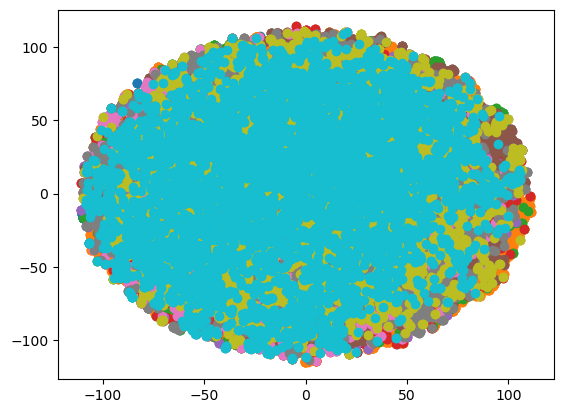

In [117]:
for i in range(10):
    plt.scatter(color_dict[i][0], color_dict[i][1])
plt.show()

Что вы думаете насчет этой картинки? Отличается от картинки для VAE? Какой-то ужас. Почему так я не понимаю. Может было бы лучше с conv сетью, но я не успеваю её сделать.

# BONUS 1: Denoising

## Внимание! За бонусы доп. баллы не ставятся, но вы можете сделать их для себя.

У автоэнкодеров, кроме сжатия и генерации изображений, есть другие практические применения. Про одно из них эта бонусная часть задания.

Автоэнкодеры могут быть использованы для избавления от шума на фотографиях (denoising). Для этого их нужно обучить специальным образом: input картинка будет зашумленной, а выдавать автоэнкодер должен будет картинку без шума.
То есть, loss-функция AE останется той же (MSE между реальной картинкой и выданной), а на вход автоэнкодеру будет подаваться зашумленная картинка.

<a href="https://ibb.co/YbRJ1nZ"><img src="https://i.ibb.co/0QD164t/Screen-Shot-2020-06-04-at-4-49-50-PM.png" alt="Screen-Shot-2020-06-04-at-4-49-50-PM" border="0"></a>

Для этого нужно взять ваш любимый датасет (датасет лиц из первой части этого задания или любой другой) и сделать копию этого датасета с шумом.

В питоне шум можно добавить так:

In [ ]:
noise_factor = 0.5
X_noisy = X + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X.shape)

In [ ]:
<тут ваш код обучения автоэнкодера на зашумленных картинках. Не забудтье разбить на train/test!>

In [ ]:
<тут проверка, как AE убирает щум с тестовых картинок. Надеюсь, все получилось =)>

# BONUS 2: Image Retrieval

## Внимание! За бонусы доп. баллы не ставятся, но вы можете сделать их для себя.

Давайте представим, что весь наш тренировочный датасет -- это большая база данных людей. И вот мы получили картинку лица какого-то человека с уличной камеры наблюдения (у нас это картинка из тестового датасета) и хотим понять, что это за человек. Что нам делать? Правильно -- берем наш VAE, кодируем картинку в латентное представление и ищем среди латентныз представлений лиц нашей базы самые ближайшие!

План:

1. Получаем латентные представления всех лиц тренировочного датасета
2. Обучаем на них LSHForest `(sklearn.neighbors.LSHForest)`, например, с `n_estimators=50`
3. Берем картинку из тестового датасета, с помощью VAE получаем ее латентный вектор
4. Ищем с помощью обученного LSHForest ближайшие из латентных представлений тренировочной базы
5. Находим лица тренировочного датасета, которым соответствуют ближайшие латентные представления, визуализируем!

Немного кода вам в помощь: (feel free to delete everything and write your own)

In [ ]:
codes = <поучите латентные представления картинок из трейна>

In [ ]:
# обучаем LSHForest
from sklearn.neighbors import LSHForest
lshf = LSHForest(n_estimators=50).fit(codes)

In [ ]:
def get_similar(image, n_neighbors=5):
  # функция, которая берет тестовый image и с помощью метода kneighbours у LSHForest ищет ближайшие векторы
  # прогоняет векторы через декодер и получает картинки ближайших людей

  code = <получение латентного представления image>

  (distances,),(idx,) = lshf.kneighbors(code, n_neighbors=n_neighbors)

  return distances, X_train[idx]

In [ ]:
def show_similar(image):

  # функция, которая принимает тестовый image, ищет ближайшие к нему и визуализирует результат

    distances,neighbors = get_similar(image,n_neighbors=11)

    plt.figure(figsize=[8,6])
    plt.subplot(3,4,1)
    plt.imshow(image.cpu().numpy().transpose([1,2,0]))
    plt.title("Original image")

    for i in range(11):
        plt.subplot(3,4,i+2)
        plt.imshow(neighbors[i].cpu().numpy().transpose([1,2,0]))
        plt.title("Dist=%.3f"%distances[i])
    plt.show()

In [ ]:
<тут выведите самые похожие лица к какому-нибудь лицу из тестовой части датасета>